# Activation Functions: Code Companion

Optional background: [notes](03_Activation_Functions_Notes.ipynb). We will start with three scores, visualize activation shapes and slopes, and use two ReLU units to express XOR. Finally, we will inspect a tiny chain of derivatives and compare sigmoid with softmax outputs.

Run all cells from a fresh kernel using the [README setup](README.md). Requirements are PyTorch, NumPy, and Matplotlib. Everything runs locally on CPU, with no downloads. Parameters are fixed and hand-set; there is no training, data split, or claim about generalization. Logic tables and plotted grids are demonstrations, not benchmark datasets.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| NumPy:", np.__version__)
print("Device: CPU | fixed computations, no training")

Python: 3.9.6
PyTorch: 2.2.2 | NumPy: 1.26.4
Device: CPU | fixed computations, no training


## Three scores, several response rules

Predict the outputs for negative, zero, and positive scores. The same input tensor is passed independently to each activation. Leaky ReLU uses an explicit negative-side slope of 0.1. GELU is included as a smooth comparison; mastering it is not required for this lesson.

In [2]:
activations = {
    "Identity": nn.Identity(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.1),
    "GELU": nn.GELU(),
}
z = torch.tensor([-2., 0., 2.])
print("Scores:", z.tolist(), "| shape:", tuple(z.shape))
for name, activation in activations.items():
    result = activation(z)
    print(f"{name:12s}: " + " ".join(f"{v.item():8.3f}" for v in result))
    assert result.shape == z.shape
torch.testing.assert_close(activations["ReLU"](z), torch.tensor([0., 0., 2.]))

Scores: [-2.0, 0.0, 2.0] | shape: (3,)
Identity    :   -2.000    0.000    2.000
Sigmoid     :    0.119    0.500    0.881
Tanh        :   -0.964    0.000    0.964
ReLU        :    0.000    0.000    2.000
Leaky ReLU  :   -0.200    0.000    2.000
GELU        :   -0.046    0.000    1.954


## Plot response and local slope together

The derivative is the local slope: how sensitive output is to a small change in score. `requires_grad=True` asks PyTorch to track derivatives with respect to that input. Since these activations are elementwise, differentiating the sum of outputs gives each input's own slope. This shortcut is not a general way to recover all derivatives for coupled functions such as softmax.

`detach()` removes gradient tracking before converting values to NumPy for plotting. ReLU and leaky ReLU have corners at zero; any reported value exactly there follows the library's chosen gradient convention, rather than an ordinary derivative.

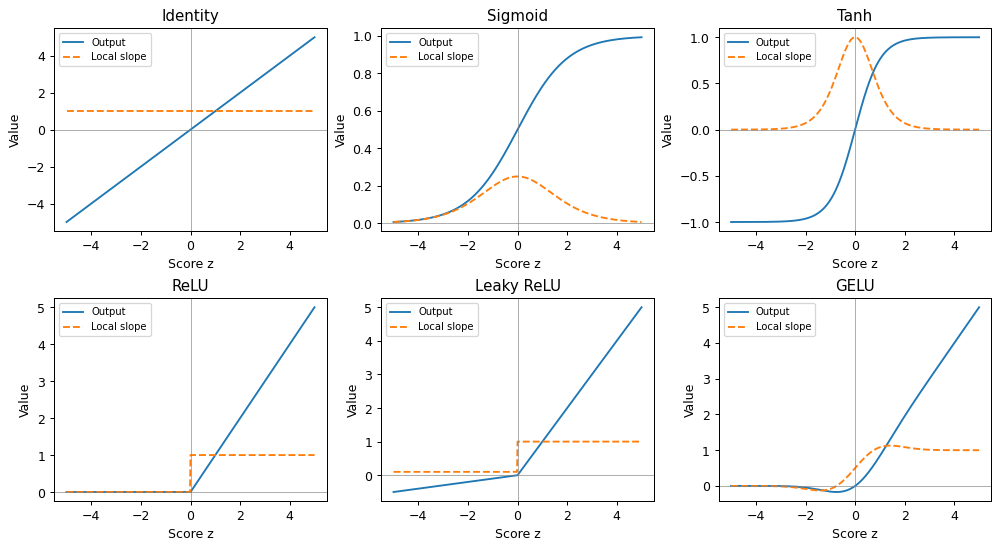

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), constrained_layout=True)
for ax, (name, activation) in zip(axes.ravel(), activations.items()):
    scores = torch.linspace(-5, 5, 501, requires_grad=True)
    outputs = activation(scores)
    slopes, = torch.autograd.grad(outputs.sum(), scores)
    ax.plot(scores.detach().numpy(), outputs.detach().numpy(), label="Output")
    ax.plot(scores.detach().numpy(), slopes.detach().numpy(), "--", label="Local slope")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set(title=name, xlabel="Score z", ylabel="Value")
    ax.legend(fontsize=8)
plt.show()

## Measure saturation and the negative side

At large magnitudes, sigmoid and tanh respond weakly to small score changes. ReLU keeps slope 1 on the positive side but has slope zero on the negative side. Leaky ReLU keeps the specified small slope there. We check sigmoid's autograd result against its analytical derivative, output × (1 − output).

This is an inspection of local slopes; a whole network's gradient also depends on weights and other computation paths.

In [4]:
probe = torch.tensor([-8., -2., 0., 2., 8.], dtype=torch.float64, requires_grad=True)
print("Scores:", probe.detach().tolist())
for name in ["Sigmoid", "Tanh", "ReLU", "Leaky ReLU"]:
    values = activations[name](probe)
    slopes, = torch.autograd.grad(values.sum(), probe)
    print(f"{name:12s} slopes: " + " ".join(f"{v.item():.6f}" for v in slopes))
    if name == "Sigmoid":
        torch.testing.assert_close(slopes, values.detach() * (1 - values.detach()))
print("ReLU's reported gradient at exactly zero is PyTorch's convention: 0.")

Scores: [-8.0, -2.0, 0.0, 2.0, 8.0]
Sigmoid      slopes: 0.000335 0.104994 0.250000 0.104994 0.000335
Tanh         slopes: 0.000000 0.070651 1.000000 0.070651 0.000000
ReLU         slopes: 0.000000 0.000000 0.000000 1.000000 1.000000
Leaky ReLU   slopes: 0.100000 0.100000 0.100000 1.000000 1.000000
ReLU's reported gradient at exactly zero is PyTorch's convention: 0.


## A bend prevents two affine stages from collapsing

The first two stages without activation are `h = 2x + 1` and `y = 3h - 4`, so the result is `6x - 1`. Inserting ReLU after the first stage creates a flat region below `x = -0.5`. The plot verifies the numerical construction in the notes.

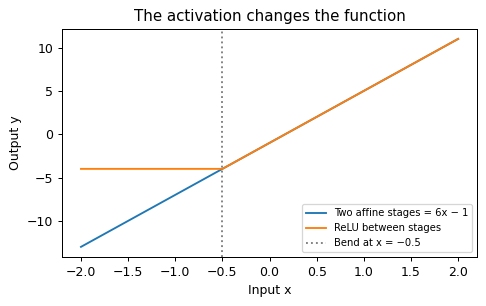

In [5]:
x = torch.linspace(-2, 2, 161)
affine_stack = 3 * (2 * x + 1) - 4
collapsed = 6 * x - 1
nonlinear_stack = 3 * torch.relu(2 * x + 1) - 4
torch.testing.assert_close(affine_stack, collapsed)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(x.numpy(), affine_stack.numpy(), label="Two affine stages = 6x − 1")
ax.plot(x.numpy(), nonlinear_stack.numpy(), label="ReLU between stages")
ax.axvline(-0.5, color="gray", linestyle=":", label="Bend at x = −0.5")
ax.set(xlabel="Input x", ylabel="Output y", title="The activation changes the function")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Express XOR with two ReLU units

The hidden weights produce `x1 − x2` and `x2 − x1`. ReLU keeps the positive difference from each unit, and the output adds them. The batch shape trace is `(4, 2) → (4, 2) → (4, 2) → (4, 1)`. The final output is a disagreement score, not a probability.

We compare the same weights with and without ReLU. The complete truth table verifies expressiveness, not successful learning: no optimizer is used. `torch.no_grad()` avoids tracking gradients during this fixed forward-pass demonstration.

In [6]:
switches = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
xor_targets = torch.tensor([[0.], [1.], [1.], [0.]])
hidden = nn.Linear(2, 2)
readout = nn.Linear(2, 1)
with torch.no_grad():
    hidden.weight.copy_(torch.tensor([[1., -1.], [-1., 1.]]))
    hidden.bias.zero_()
    readout.weight.copy_(torch.tensor([[1., 1.]]))
    readout.bias.zero_()
    hidden_scores = hidden(switches)
    hidden_values = torch.relu(hidden_scores)
    xor_scores = readout(hidden_values)
    without_activation = readout(hidden_scores)

torch.testing.assert_close(xor_scores, xor_targets)
torch.testing.assert_close(without_activation, torch.zeros_like(xor_targets))
assert torch.equal((xor_scores > 0.5).float(), xor_targets)
print("Input -> hidden scores -> hidden values -> output shapes:")
print(tuple(switches.shape), tuple(hidden_scores.shape), tuple(hidden_values.shape), tuple(xor_scores.shape))
print("x1 x2 | h1 h2 | with ReLU | without ReLU | XOR target")
for i in range(4):
    print(f" {switches[i, 0]:.0f}  {switches[i, 1]:.0f} |"
          f"  {hidden_values[i, 0]:.0f}  {hidden_values[i, 1]:.0f} |"
          f"     {xor_scores[i, 0]:.0f}     |       {without_activation[i, 0]:.0f}      |"
          f"     {xor_targets[i, 0]:.0f}")

Input -> hidden scores -> hidden values -> output shapes:
(4, 2) (4, 2) (4, 2) (4, 1)
x1 x2 | h1 h2 | with ReLU | without ReLU | XOR target
 0  0 |  0  0 |     0     |       0      |     0
 0  1 |  0  1 |     1     |       0      |     1
 1  0 |  1  0 |     1     |       0      |     1
 1  1 |  0  0 |     0     |       0      |     0


## Observe sensitivity through a scalar chain

Starting from input 1, repeatedly apply the same activation with implicit weight 1 and bias 0 at every stage. Differentiate the final output with respect to the original input. This deliberately stripped-down chain isolates activation behavior; it is not a trained network or a fair performance comparison of architectures.

Sigmoid contributes a factor at most 0.25 at each stage. ReLU stays on its positive side here, where the slope is 1. ReLU's result would be very different on a negative input. Real networks also multiply by weights and combine paths.

In [7]:
print("Depth | sigmoid output | sigmoid sensitivity | ReLU sensitivity")
for depth in [1, 2, 4, 8]:
    measurements = {}
    for name in ["Sigmoid", "ReLU"]:
        original = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
        value = original
        for _ in range(depth):
            value = activations[name](value)
        sensitivity, = torch.autograd.grad(value, original)
        measurements[name] = (value.item(), sensitivity.item())
    print(f"{depth:5d} | {measurements['Sigmoid'][0]:14.6f} |"
          f" {measurements['Sigmoid'][1]:19.3e} | {measurements['ReLU'][1]:16.3e}")

Depth | sigmoid output | sigmoid sensitivity | ReLU sensitivity
    1 |       0.731059 |           1.966e-01 |        1.000e+00
    2 |       0.675038 |           4.313e-02 |        1.000e+00
    4 |       0.659851 |           2.164e-03 |        1.000e+00
    8 |       0.659048 |           5.515e-06 |        1.000e+00


## Output probabilities: independent labels or competing classes?

For logits `(2, 1, 0)`, sigmoid treats each score independently. Softmax normalizes all three scores together so their probabilities sum to one. The last axis (`dim=-1`) is the class axis in this `(1, 3)` batch.

We also calculate softmax by subtracting each row's maximum first, and verify that adding the same constant to all logits leaves the result unchanged. These are properties of the transformation; arbitrary scores do not establish calibrated probabilities.

In [8]:
logits = torch.tensor([[2., 1., 0.]], dtype=torch.float64)
independent = torch.sigmoid(logits)
competing = torch.softmax(logits, dim=-1)
shifted = logits - logits.max(dim=-1, keepdim=True).values
exponentials = torch.exp(shifted)
manual_softmax = exponentials / exponentials.sum(dim=-1, keepdim=True)
torch.testing.assert_close(manual_softmax, competing)
torch.testing.assert_close(torch.softmax(logits + 1000, dim=-1), competing)
torch.testing.assert_close(competing.sum(dim=-1), torch.ones(1, dtype=torch.float64))
print("Logits shape:", tuple(logits.shape))
print("Independent sigmoid:", np.round(independent.numpy(), 3), "sum =", round(independent.sum().item(), 3))
print("Competing softmax:  ", np.round(competing.numpy(), 3), "sum =", round(competing.sum().item(), 3))

Logits shape: (1, 3)
Independent sigmoid: [[0.881 0.731 0.5  ]] sum = 2.112
Competing softmax:   [[0.665 0.245 0.09 ]] sum = 1.0


## Keep logits at the loss boundary

PyTorch's `BCEWithLogitsLoss` takes a raw binary score, while `CrossEntropyLoss` takes raw class scores. Sigmoid and softmax are used separately below to display probabilities. Each loss measures mismatch with an illustrative target; no parameters are updated.

For this example, binary logits and floating-point targets both have shape `(1, 1)`. Multiclass logits have shape `(1, 3)` and integer class-index targets have shape `(1,)`. The multiclass target `0` means the first class. Passing already transformed probabilities into these losses would change the intended calculation. See the official [binary](https://docs.pytorch.org/docs/2.8/generated/torch.nn.BCEWithLogitsLoss.html) and [multiclass](https://docs.pytorch.org/docs/2.8/generated/torch.nn.CrossEntropyLoss.html) references.

In [9]:
binary_logits = torch.tensor([[2.0]])
binary_target = torch.tensor([[1.0]])
binary_loss = nn.BCEWithLogitsLoss()(binary_logits, binary_target)
class_logits = torch.tensor([[2.0, 1.0, 0.0]])
class_target = torch.tensor([0], dtype=torch.long)
class_loss = nn.CrossEntropyLoss()(class_logits, class_target)
print(f"Binary probability for class 1: {torch.sigmoid(binary_logits).item():.3f}")
print(f"Binary loss from logits: {binary_loss.item():.3f}")
print("Multiclass probabilities:", np.round(torch.softmax(class_logits, dim=-1).numpy(), 3))
print(f"Multiclass loss from logits: {class_loss.item():.3f}")
assert torch.isfinite(binary_loss) and torch.isfinite(class_loss)

Binary probability for class 1: 0.881
Binary loss from logits: 0.127
Multiclass probabilities: [[0.665 0.245 0.09 ]]
Multiclass loss from logits: 0.408


## What the demonstrations establish

Activations change the functions a network can express and the local slopes through which changes propagate. The XOR example proves that a particular nonlinear construction represents the truth table; it does not show how weights are learned. The scalar chain exposes one reason gradients may shrink, not the behavior of every deep network. Output activation choices also depend on whether predictions are independent or competing.

## Try it yourself

- Change leaky ReLU's negative slope from 0.1 to 0.01. Predict its output at -2 and its negative-side slope, then rerun the curve and probe cells.
- Replace `torch.relu(hidden_scores)` in the XOR construction with `hidden_scores`. The assertion should fail because the scores cancel. Explain the failure before restoring the activation.
- Change the scalar-chain starting input from 1 to -1. What happens to ReLU sensitivity? Why does this not contradict its positive-side slope of 1?
- Change the third multiclass logit from 0 to 3. Predict which softmax probabilities change. Compare with sigmoid: only the changed score's sigmoid output changes.

Restart and run all cells after each independent experiment. Restore intentional breaking changes before expecting the verification assertions to pass. No dataset or test set is needed for these deterministic calculations.